In [114]:
import numpy as np
import pandas as pd
import os
import glob
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Activation, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K

# PATHS 
BASE_PATH = '/kaggle/input/fall-2025-pu-prl-lab-performance-1'
SAMPLES_DIR = '/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/mnist-bengali/samples'
TRAIN_CSV = '/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/train.csv'

# Constants
RESIZE_DIM = 28 

# Monitoring Output
print(f"Samples directory exists: {os.path.exists(SAMPLES_DIR)}")
print(f"Train CSV exists: {os.path.exists(TRAIN_CSV)}")
sample_count = len(os.listdir(SAMPLES_DIR))
print(f"Total image files found: {sample_count}")

Samples directory exists: True
Train CSV exists: True
Total image files found: 61137


Data Loading & Image Processing Pipeline

In [116]:
def prepare_data(csv_path, img_dir, resize_dim=28):
    df = pd.read_csv(csv_path)
    X, y_label = [], []
    
    print("Beginning image enhancement pipeline...")
    for i, row in df.iterrows():
        img_path = os.path.join(img_dir, row['filename'])
        
        # Load and resize
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (resize_dim, resize_dim), interpolation=cv2.INTER_AREA)
        
        # Enhancement: Sharpening using Gaussian unblur
        gauss = cv2.GaussianBlur(img, (9,9), 10.0)
        img = cv2.addWeighted(img, 1.5, gauss, -0.5, 0)
        
        # Enhancement: Binary Thresholding
        _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        X.append(img)
        # labels if exist (for training)
        if 'digit' in row:
            y_label.append(row['digit'])
        
        if i % 2000 == 0:
            print(f"Processed {i} images...", end="\r")
            
    X = np.array(X).reshape(-1, resize_dim, resize_dim, 1).astype('float32') / 255.0
    y = to_categorical(y_label, 10) if y_label else None
    return X, y

X_full, y_full = prepare_data(TRAIN_CSV, SAMPLES_DIR, RESIZE_DIM)
print(f"\nData processing finished. Shape: {X_full.shape}")

Beginning image enhancement pipeline...
Processed 36000 images...
Data processing finished. Shape: (36682, 64, 64, 1)


Train-Test Split & Data Augmentation

In [133]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Stratified Split (85% Train, 15% Val)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.15, random_state=42, stratify=np.argmax(y_full, axis=1)
)

# 2. Augmentation 
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    fill_mode='nearest'
)

print(f"Split Complete. Training on {len(X_train)} samples, Validating on {len(X_val)} samples.")

Split Complete. Training on 31179 samples, Validating on 5503 samples.


ResNet-50 Architecture & Training

In [129]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

def build_resnet_model(input_shape=(RESIZE_DIM, RESIZE_DIM, 1)):
    input_tensor = Input(shape=input_shape)
    x = Concatenate()([input_tensor, input_tensor, input_tensor])
    
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=x)
    
    # Fine-tune the last 50 layers for specific Bengali digit features
    for layer in base_model.layers[:-50]:
        layer.trainable = False
        
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x) 
    predictions = Dense(10, activation='softmax')(x)
    
    model = Model(inputs=input_tensor, outputs=predictions)
    
    model.compile(
        optimizer=Adam(learning_rate=1e-4), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

model = build_resnet_model()

callbacks = [
    # Saved best model based on validation accuracy
    ModelCheckpoint('best_resnet_bengali.h5', save_best_only=True, monitor='val_accuracy', mode='max'),
    
    # Early Stopping
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    
    # Reduce Lower learning rate if progress stalls
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, verbose=1, min_lr=1e-7)
]

print("Starting Training with Early Stopping...")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=40, 
    callbacks=callbacks,
    verbose=1 
)

Starting Training with Early Stopping...
Epoch 1/40
973/975 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5494 - loss: 1.3151

975/975 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.5497 - loss: 1.3140 - val_accuracy: 0.6740 - val_loss: 0.9999 - learning_rate: 1.0000e-04
Epoch 2/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7856 - loss: 0.6315

975/975 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.7856 - loss: 0.6314 - val_accuracy: 0.8210 - val_loss: 0.5407 - learning_rate: 1.0000e-04
Epoch 3/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8195 - loss: 0.5323

975/975 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.8195 - loss: 0.5323 - val_accuracy: 0.8735 - val_loss: 0.3594 - learning_rate: 1.0000e-04
Epoch 4/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.8450 - loss: 0.4478 - val_accuracy: 0.6904 - val_loss: 1.0959 - learning_rate: 1.0000e-04
Epoch 5/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.8592 - loss: 0.4131 - val_accuracy: 0.8232 - val_loss: 0.5217 - learning_rate: 1.0000e-04
Epoch 6/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8737 - loss: 0.3718

975/975 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.8737 - loss: 0.3718 - val_accuracy: 0.8995 - val_loss: 0.2899 - learning_rate: 1.0000e-04
Epoch 7/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.8815 - loss: 0.3504 - val_accuracy: 0.8239 - val_loss: 0.6187 - learning_rate: 1.0000e-04
Epoch 8/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.8809 - loss: 0.3466 - val_accuracy: 0.8216 - val_loss: 0.6309 - learning_rate: 1.0000e-04
Epoch 9/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.8910 - loss: 0.3160 - val_accuracy: 0.7643 - val_loss: 0.9002 - learning_rate: 1.0000e-04
Epoch 10/40
973/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8997 - loss: 0.2950
Epoch 10: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.8997 - loss: 0.2950 - val_accuracy: 0.8737 - val_loss: 0.3873 - learning_rate: 1.0000e-04
Epoch 11/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 

975/975 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9202 - loss: 0.2306 - val_accuracy: 0.9468 - val_loss: 0.1549 - learning_rate: 2.0000e-05
Epoch 12/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9327 - loss: 0.2031 - val_accuracy: 0.9391 - val_loss: 0.1796 - learning_rate: 2.0000e-05
Epoch 13/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9344 - loss: 0.1908

975/975 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9344 - loss: 0.1908 - val_accuracy: 0.9488 - val_loss: 0.1568 - learning_rate: 2.0000e-05
Epoch 14/40
974/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9371 - loss: 0.1786

975/975 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9371 - loss: 0.1786 - val_accuracy: 0.9551 - val_loss: 0.1328 - learning_rate: 2.0000e-05
Epoch 15/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9436 - loss: 0.1666 - val_accuracy: 0.9395 - val_loss: 0.1781 - learning_rate: 2.0000e-05
Epoch 16/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9430 - loss: 0.1679 - val_accuracy: 0.9437 - val_loss: 0.1766 - learning_rate: 2.0000e-05
Epoch 17/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9460 - loss: 0.1588 - val_accuracy: 0.9299 - val_loss: 0.2235 - learning_rate: 2.0000e-05
Epoch 18/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9454 - loss: 0.1592
Epoch 18: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9454 - loss: 0.1592 - val_accuracy: 0.9548 - val_loss: 0.1345 - learning_rate: 2.0000e-05
Epoch 19/40
974/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy

975/975 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9499 - loss: 0.1433 - val_accuracy: 0.9624 - val_loss: 0.1135 - learning_rate: 4.0000e-06
Epoch 20/40
973/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9540 - loss: 0.1358

975/975 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9540 - loss: 0.1358 - val_accuracy: 0.9658 - val_loss: 0.1064 - learning_rate: 4.0000e-06
Epoch 21/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9523 - loss: 0.1368 - val_accuracy: 0.9613 - val_loss: 0.1190 - learning_rate: 4.0000e-06
Epoch 22/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9541 - loss: 0.1376 - val_accuracy: 0.9595 - val_loss: 0.1255 - learning_rate: 4.0000e-06
Epoch 23/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9519 - loss: 0.1407 - val_accuracy: 0.9635 - val_loss: 0.1169 - learning_rate: 4.0000e-06
Epoch 24/40
974/975 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9553 - loss: 0.1277
Epoch 24: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9554 - loss: 0.1277 - val_accuracy: 0.9642 - val_loss: 0.1104 - learning_rate: 4.0000e-06
Epoch 25/40
975/975 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accurac

Model Evaluation & Metrics

Generating predictions for validation set...
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Digit 0       0.98      0.98      0.98       552
     Digit 1       0.90      0.94      0.92       548
     Digit 2       0.99      0.99      0.99       551
     Digit 3       0.98      0.95      0.97       551
     Digit 4       0.96      0.98      0.97       553
     Digit 5       0.95      0.97      0.96       552
     Digit 6       0.97      0.95      0.96       553
     Digit 7       0.99      0.99      0.99       550
     Digit 8       1.00      0.99      0.99       546
     Digit 9       0.95      0.91      0.93       547

    accuracy                           0.97      5503
   macro avg       0.97      0.97      0.97      5503
weighted avg       0.97      0.97      0.97      5503



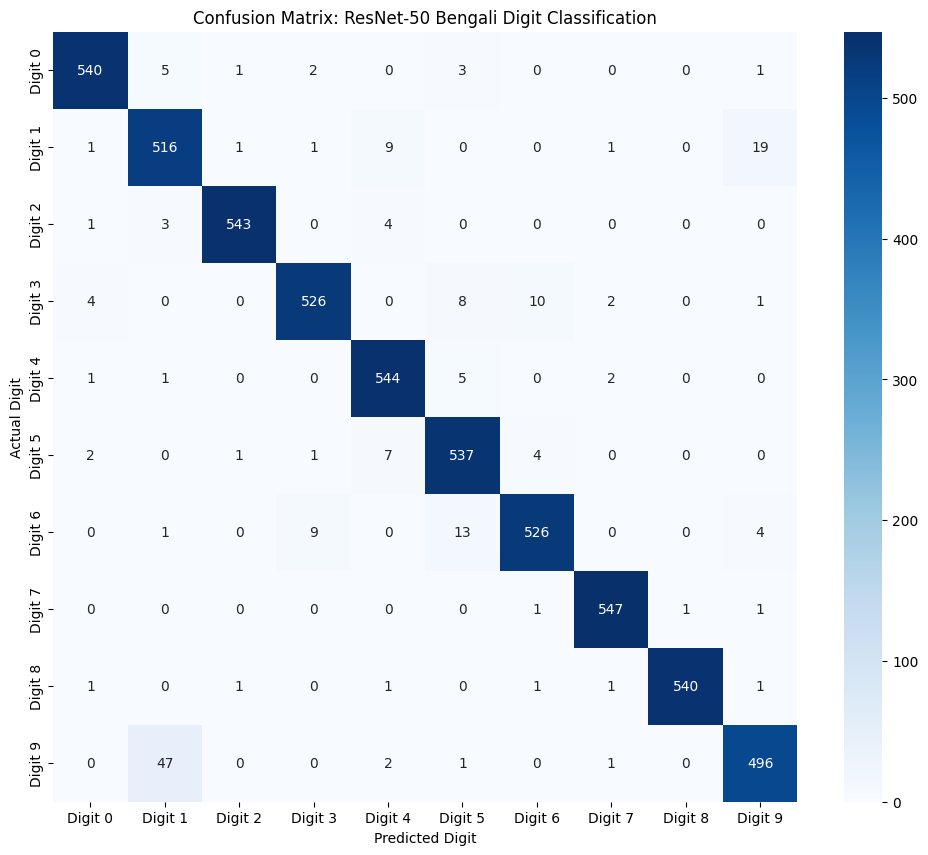

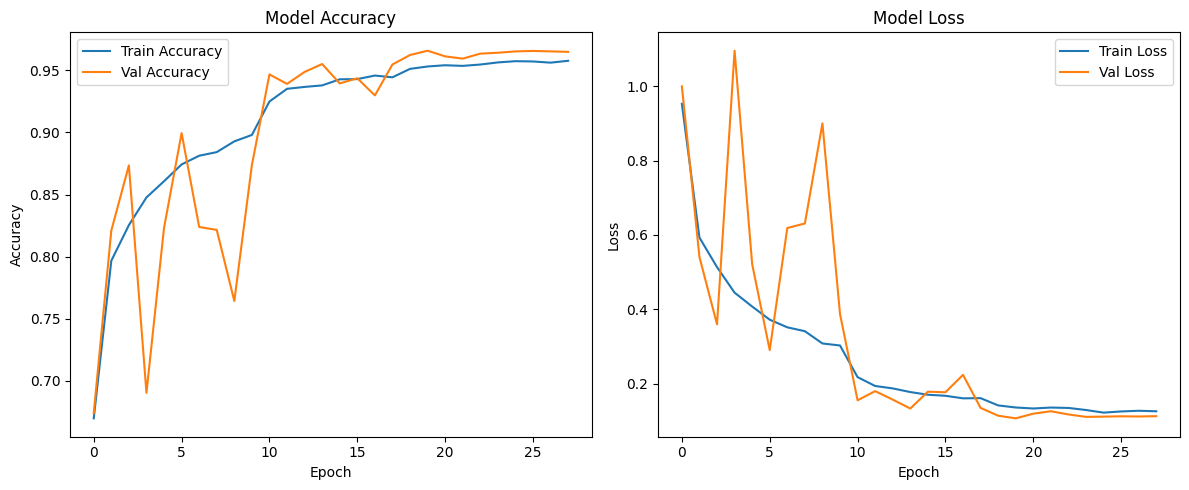

In [130]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Predictions on Validation Set
print("Generating predictions for validation set...")
y_pred_probs = model.predict(X_val, batch_size=64, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

# 2. Detailed Classification 
print("\n--- Detailed Classification Report ---")
# Mapping 0-9 for Bengali digits
target_names = [f'Digit {i}' for i in range(10)]
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: ResNet-50 Bengali Digit Classification')
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.show()

# 4. Accuracy/Loss Curves from Training History
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Prediction & Final Submission File

In [132]:
import numpy as np

# best weights found during training
model.load_weights('best_resnet_bengali.h5')

# Sample Submission template loaded
SUB_TEMPLATE = '/kaggle/input/competitions/fall-2025-pu-prl-lab-performance-1/sample_submission.csv'
sub_df = pd.read_csv(SUB_TEMPLATE)

X_test = []
print("🔍 Processing test set images...")

for i, row in sub_df.iterrows():
    img_path = os.path.join(SAMPLES_DIR, row['filename'])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # EXACT SAME enhancement from Cell 
    img = cv2.resize(img, (RESIZE_DIM, RESIZE_DIM), interpolation=cv2.INTER_AREA)
    gauss = cv2.GaussianBlur(img, (9,9), 10.0)
    img = cv2.addWeighted(img, 1.5, gauss, -0.5, 0)
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    X_test.append(img)
    if i % 5000 == 0: print(f"Processed {i} test images...", end="\r")

# Reshape and Normalize
X_test = np.array(X_test).reshape(-1, RESIZE_DIM, RESIZE_DIM, 1).astype('float32') / 255.0

# Run Inference
print("\n🧠 Generating predictions...")
preds = model.predict(X_test, batch_size=64, verbose=1)
sub_df['digit'] = np.argmax(preds, axis=1)

# Final Export
sub_df.to_csv('submission.csv', index=False)
print("submission.csv is ready for upload")

🔍 Processing test set images...
Processed 20000 test images...
🧠 Generating predictions...
383/383 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
submission.csv is ready for upload
